# Goal:

The goal of this project is to understand "What increases the probability of winning a match?”

In [2]:
#import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Loading in EPL 2023/24 match results
path = r"C:\Users\jahg9\OneDrive\Documents\Data Analysis Projects\EPL Match Prediction\matches.csv"
epl = pd.read_csv(path)

# EDA

In [138]:
epl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    760 non-null    int64  
 1   Date          760 non-null    object 
 2   Time          760 non-null    object 
 3   Comp          760 non-null    object 
 4   Round         760 non-null    object 
 5   Day           760 non-null    object 
 6   Venue         760 non-null    object 
 7   Result        760 non-null    object 
 8   GF            760 non-null    int64  
 9   GA            760 non-null    int64  
 10  Opponent      760 non-null    object 
 11  xG            760 non-null    float64
 12  xGA           760 non-null    float64
 13  Poss          760 non-null    float64
 14  Attendance    760 non-null    float64
 15  Captain       760 non-null    object 
 16  Formation     760 non-null    object 
 17  Referee       760 non-null    object 
 18  Match Report  760 non-null    

In [139]:
epl.describe()

,Unnamed: 0,GF,GA,xG,xGA,Poss,Attendance,Notes,Sh,SoT,Dist,FK,PK,PKatt,Season
count,760.000000,760.000000,760.000000,760.000000,760.000000,760.0000,760.000000,0.0,760.000000,760.000000,760.000000,760.000000,760.000000,760.000000,760.0
mean,24.051316,1.639474,1.639474,1.550263,1.550263,50.0000,38613.313158,NaN,13.660526,4.668421,16.711842,0.372368,0.126316,0.140789,2024.0
std,14.518127,1.331297,1.331297,0.891314,0.891314,13.7495,17952.911952,NaN,6.058391,2.645612,2.856164,0.598218,0.359097,0.377104,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.0000,10290.000000,NaN,1.000000,0.000000,7.000000,0.000000,0.000000,0.000000,2024.0
25%,11.750000,1.000000,1.000000,0.900000,0.900000,40.0000,24444.750000,NaN,9.000000,3.000000,14.900000,0.000000,0.000000,0.000000,2024.0
50%,24.000000,1.000000,1.000000,1.400000,1.400000,50.0000,38181.000000,NaN,13.000000,4.000000,16.700000,0.000000,0.000000,0.000000,2024.0
75%,36.000000,2.000000,2.000000,2.100000,2.100000,60.0000,53371.750000,NaN,17.000000,6.000000,18.400000,1.000000,0.000000,0.000000,2024.0
max,57.000000,8.000000,8.000000,7.000000,7.000000,82.0000,73612.000000,NaN,36.000000,15.000000,39.900000,3.000000,2.000000,2.000000,2024.0


In [140]:
epl.columns

Index(['Unnamed: 0', 'Date', 'Time', 'Comp', 'Round', 'Day', 'Venue', 'Result',
       'GF', 'GA', 'Opponent', 'xG', 'xGA', 'Poss', 'Attendance', 'Captain',
       'Formation', 'Referee', 'Match Report', 'Notes', 'Sh', 'SoT', 'Dist',
       'FK', 'PK', 'PKatt', 'Season', 'Team'],
      dtype='object')

In [141]:
epl.shape

(760, 28)

In [142]:
epl.drop(columns=['Unnamed: 0', 'Notes'], inplace=True)

In [143]:
epl.head()

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent,...,Referee,Match Report,Sh,SoT,Dist,FK,PK,PKatt,Season,Team
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,3,0,Burnley,...,Craig Pawson,Match Report,17.0,8.0,13.9,0.0,0,0,2024,ManchesterCity
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,1,0,Newcastle Utd,...,Robert Jones,Match Report,14.0,4.0,17.9,0.0,0,0,2024,ManchesterCity
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,2,1,Sheffield Utd,...,Jarred Gillett,Match Report,29.0,9.0,17.3,2.0,0,1,2024,ManchesterCity
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,5,1,Fulham,...,Michael Oliver,Match Report,6.0,4.0,14.8,0.0,1,1,2024,ManchesterCity
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,3,1,West Ham,...,Andy Madley,Match Report,29.0,13.0,16.4,1.0,0,0,2024,ManchesterCity


In [144]:
epl['Team'].unique()

array(['ManchesterCity', 'Arsenal', 'Liverpool', 'AstonVilla',
       'TottenhamHotspur', 'Chelsea', 'NewcastleUnited',
       'ManchesterUnited', 'WestHamUnited', 'CrystalPalace',
       'BrightonandHoveAlbion', 'Bournemouth', 'Fulham',
       'WolverhamptonWanderers', 'Everton', 'Brentford',
       'NottinghamForest', 'LutonTown', 'Burnley', 'SheffieldUnited'],
      dtype=object)

# Creating Features

In [145]:
#Creating goal difference column
epl['GD'] = epl['GF'] = epl['GA']
#Creating expected goal difference column
epl['xGD'] = epl['xG'] - epl['xGA']
# Encode wins as a 1
epl['win'] = (epl['Result'] == 'W').astype(int)

In [146]:
epl['Date'] = pd.to_datetime(epl['Date']).dt.date
epl['Time'] = epl['Time'].str.strip()
epl['Referee'] = epl['Referee'].str.strip()

epl.head()



,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent,...,SoT,Dist,FK,PK,PKatt,Season,Team,GD,xGD,win
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,0,0,Burnley,...,8.0,13.9,0.0,0,0,2024,ManchesterCity,0,1.6,1
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,0,0,Newcastle Utd,...,4.0,17.9,0.0,0,0,2024,ManchesterCity,0,0.7,1
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,1,1,Sheffield Utd,...,9.0,17.3,2.0,0,1,2024,ManchesterCity,1,2.8,1
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,1,1,Fulham,...,4.0,14.8,0.0,1,1,2024,ManchesterCity,1,0.8,1
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,1,1,West Ham,...,13.0,16.4,1.0,0,0,2024,ManchesterCity,1,2.7,1


In [147]:
epl_opp = epl[['Date', 'Time', 'Referee', 'Team', 'Sh', 'SoT', 'Venue']].copy()


epl_opp.columns = [
    'Date', 'Time', 'Referee',
    'Opponent', 'Opp_Sh', 'Opp_SoT', 'Venue'
]


# flip venue so Home matches Away and vice versa
epl_opp['Venue'] = epl_opp['Venue'].map({
    'Home': 'Away',
    'Away': 'Home'
})


In [148]:
epl_merged = epl.merge(
    epl_opp,
    on=['Date', 'Time', 'Referee', 'Venue'],
    how='left'
)

#Why did the shape change when including/excluding venue?

epl_merged.shape


(760, 32)

In [149]:
matchkey = ['Date', 'Time', 'Referee', 'Venue']

epl_merged.groupby(matchkey).size().value_counts()


1    760
Name: count, dtype: int64

In [150]:
epl_merged.head()

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent_x,...,PK,PKatt,Season,Team,GD,xGD,win,Opponent_y,Opp_Sh,Opp_SoT
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,0,0,Burnley,...,0,0,2024,ManchesterCity,0,1.6,1,Burnley,6.0,1.0
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,0,0,Newcastle Utd,...,0,0,2024,ManchesterCity,0,0.7,1,NewcastleUnited,7.0,1.0
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,1,1,Sheffield Utd,...,0,1,2024,ManchesterCity,1,2.8,1,SheffieldUnited,6.0,1.0
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,1,1,Fulham,...,1,1,2024,ManchesterCity,1,0.8,1,Fulham,6.0,4.0
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,1,1,West Ham,...,0,0,2024,ManchesterCity,1,2.7,1,WestHamUnited,6.0,3.0


In [151]:
# Compute shot difference (team shots minus opponent shots)
epl_merged['shot_diff'] = epl_merged['Sh'] - epl_merged['Opp_Sh']

# Compute shots-on-target difference
epl_merged['sot_diff'] = epl_merged['SoT'] - epl_merged['Opp_SoT']


In [152]:
epl_merged.head()


,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent_x,...,Season,Team,GD,xGD,win,Opponent_y,Opp_Sh,Opp_SoT,shot_diff,sot_diff
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,0,0,Burnley,...,2024,ManchesterCity,0,1.6,1,Burnley,6.0,1.0,11.0,7.0
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,0,0,Newcastle Utd,...,2024,ManchesterCity,0,0.7,1,NewcastleUnited,7.0,1.0,7.0,3.0
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,1,1,Sheffield Utd,...,2024,ManchesterCity,1,2.8,1,SheffieldUnited,6.0,1.0,23.0,8.0
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,1,1,Fulham,...,2024,ManchesterCity,1,0.8,1,Fulham,6.0,4.0,0.0,0.0
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,1,1,West Ham,...,2024,ManchesterCity,1,2.7,1,WestHamUnited,6.0,3.0,23.0,10.0


# Confirming Merge Worked

In [153]:
epl_merged.groupby(['Date', 'Time', 'Referee'])['sot_diff'].sum()


Date        Time   Referee       
2023-08-11  20:00  Craig Pawson      0.0
2023-08-12  12:30  Michael Oliver    0.0
            15:00  David Coote       0.0
                   John Brooks       0.0
                   Peter Bankes      0.0
                                    ... 
2024-05-19  16:00  Graham Scott      0.0
                   John Brooks       0.0
                   Matt Donohue      0.0
                   Michael Oliver    0.0
                   Simon Hooper      0.0
Name: sot_diff, Length: 380, dtype: float64

In [154]:
epl_merged.head()

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent_x,...,Season,Team,GD,xGD,win,Opponent_y,Opp_Sh,Opp_SoT,shot_diff,sot_diff
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,0,0,Burnley,...,2024,ManchesterCity,0,1.6,1,Burnley,6.0,1.0,11.0,7.0
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,0,0,Newcastle Utd,...,2024,ManchesterCity,0,0.7,1,NewcastleUnited,7.0,1.0,7.0,3.0
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,1,1,Sheffield Utd,...,2024,ManchesterCity,1,2.8,1,SheffieldUnited,6.0,1.0,23.0,8.0
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,1,1,Fulham,...,2024,ManchesterCity,1,0.8,1,Fulham,6.0,4.0,0.0,0.0
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,1,1,West Ham,...,2024,ManchesterCity,1,2.7,1,WestHamUnited,6.0,3.0,23.0,10.0


In [155]:
epl_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 34 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Date          760 non-null    object 
 1   Time          760 non-null    object 
 2   Comp          760 non-null    object 
 3   Round         760 non-null    object 
 4   Day           760 non-null    object 
 5   Venue         760 non-null    object 
 6   Result        760 non-null    object 
 7   GF            760 non-null    int64  
 8   GA            760 non-null    int64  
 9   Opponent_x    760 non-null    object 
 10  xG            760 non-null    float64
 11  xGA           760 non-null    float64
 12  Poss          760 non-null    float64
 13  Attendance    760 non-null    float64
 14  Captain       760 non-null    object 
 15  Formation     760 non-null    object 
 16  Referee       760 non-null    object 
 17  Match Report  760 non-null    object 
 18  Sh            760 non-null    

In [156]:
#Creating additional features
epl_merged['shot_diff'] = epl_merged['Sh'] - epl_merged['Opp_Sh']
epl_merged['sot_diff'] = epl_merged['SoT'] - epl_merged['Opp_SoT']


In [157]:
epl_merged[epl_merged['shot_diff'].isnull()]

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent_x,...,Season,Team,GD,xGD,win,Opponent_y,Opp_Sh,Opp_SoT,shot_diff,sot_diff


In [158]:
epl_merged.shape

(760, 34)

In [159]:
epl_merged.head()

,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent_x,...,Season,Team,GD,xGD,win,Opponent_y,Opp_Sh,Opp_SoT,shot_diff,sot_diff
0,2023-08-11,20:00,Premier League,Matchweek 1,Fri,Away,W,0,0,Burnley,...,2024,ManchesterCity,0,1.6,1,Burnley,6.0,1.0,11.0,7.0
1,2023-08-19,20:00,Premier League,Matchweek 2,Sat,Home,W,0,0,Newcastle Utd,...,2024,ManchesterCity,0,0.7,1,NewcastleUnited,7.0,1.0,7.0,3.0
2,2023-08-27,14:00,Premier League,Matchweek 3,Sun,Away,W,1,1,Sheffield Utd,...,2024,ManchesterCity,1,2.8,1,SheffieldUnited,6.0,1.0,23.0,8.0
3,2023-09-02,15:00,Premier League,Matchweek 4,Sat,Home,W,1,1,Fulham,...,2024,ManchesterCity,1,0.8,1,Fulham,6.0,4.0,0.0,0.0
4,2023-09-16,15:00,Premier League,Matchweek 5,Sat,Away,W,1,1,West Ham,...,2024,ManchesterCity,1,2.7,1,WestHamUnited,6.0,3.0,23.0,10.0


# Encode result as a binary variable

In [160]:
epl_merged['win'] = (epl_merged['Result'] == 'W').astype(int)

## Data Plots

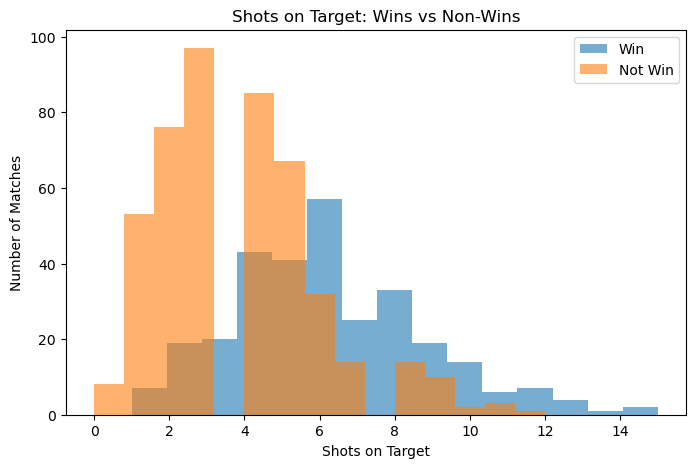

In [161]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    epl_merged.loc[epl_merged['win'] == 1, 'SoT'],
    bins=15,
    alpha=0.6,
    label='Win'
)

plt.hist(
    epl_merged.loc[epl_merged['win'] == 0, 'SoT'],
    bins=15,
    alpha=0.6,
    label='Not Win'
)

plt.xlabel('Shots on Target')
plt.ylabel('Number of Matches')
plt.title('Shots on Target: Wins vs Non-Wins')
plt.legend()

plt.show()


This histogram shows that as teams generate more shots on target, they are more likely to win matches vs teams that generate less shots on target. 

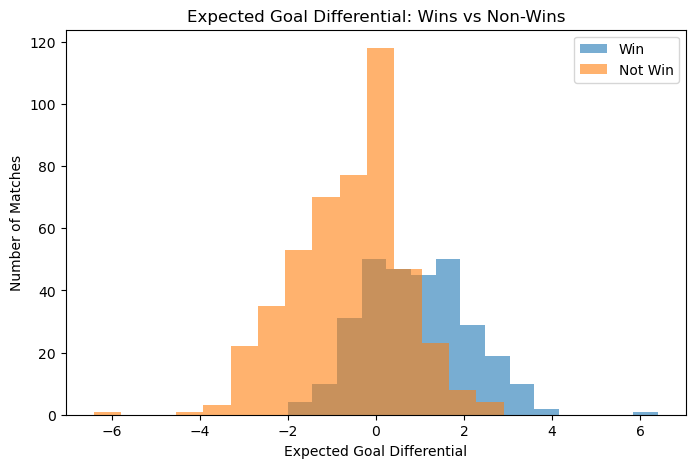

In [162]:
plt.figure(figsize=(8, 5))

plt.hist(
    epl_merged.loc[epl_merged['win'] == 1, 'xGD'],
    bins=15,
    alpha=0.6,
    label='Win'
)

plt.hist(
    epl_merged.loc[epl_merged['win'] == 0, 'xGD'],
    bins=15,
    alpha=0.6,
    label='Not Win'
)

plt.xlabel('Expected Goal Differential')
plt.ylabel('Number of Matches')
plt.title('Expected Goal Differential: Wins vs Non-Wins')
plt.legend()

plt.show()

The histogram shows a clear rightward shift in expected goal differential for wins versus non-wins, indicating that teams generating higher-quality chances than their opponents are substantially more likely to win, with overlap near zero reflecting inherent match randomness.

In [163]:
epl_merged.columns

Index(['Date', 'Time', 'Comp', 'Round', 'Day', 'Venue', 'Result', 'GF', 'GA',
       'Opponent_x', 'xG', 'xGA', 'Poss', 'Attendance', 'Captain', 'Formation',
       'Referee', 'Match Report', 'Sh', 'SoT', 'Dist', 'FK', 'PK', 'PKatt',
       'Season', 'Team', 'GD', 'xGD', 'win', 'Opponent_y', 'Opp_Sh', 'Opp_SoT',
       'shot_diff', 'sot_diff'],
      dtype='object')

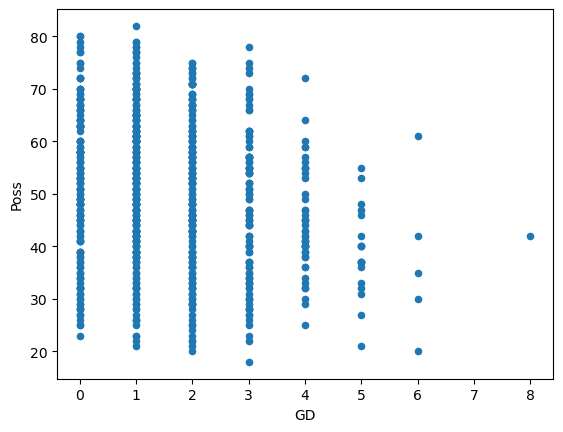

In [164]:
epl_merged.plot.scatter(x='GD', y='Poss')
plt.show()

The scatter plot shows that possession varies widely across all goal differences, indicating that possession alone is a weak predictor of match outcomes.

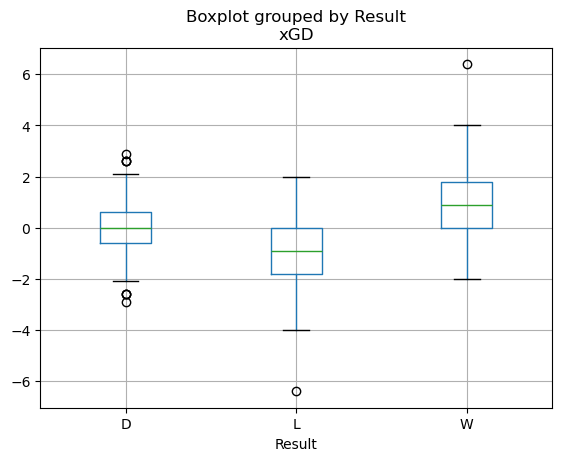

In [165]:
epl_merged.boxplot(column='xGD', by='Result')
plt.show()

Wins are associated with hgiher xGD on average than Draws and losses. The XGD median, min and maximum values are higher than losses and draws indicating that more expected goals gives a hgiher chance of winning a match. 

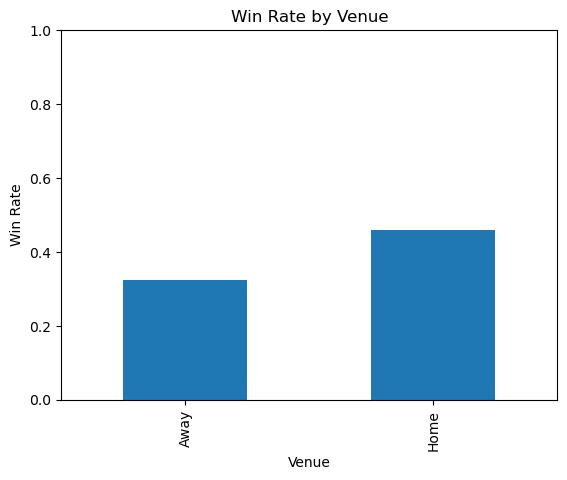

In [166]:
import matplotlib.pyplot as plt

win_rate = (
    epl_merged
    .groupby('Venue')['win']
    .mean()
)

win_rate.plot(kind='bar')

plt.ylabel('Win Rate')
plt.title('Win Rate by Venue')
plt.ylim(0, 1)
plt.show()



# Feature Selection

In [167]:
corr = epl_merged.select_dtypes(include='number').corr()
corr


,GF,GA,xG,xGA,Poss,Attendance,Sh,SoT,Dist,FK,PK,PKatt,Season,GD,xGD,win,Opp_Sh,Opp_SoT,shot_diff,sot_diff
GF,1.000000,1.000000,-0.229203,0.596994,-2.101021e-01,2.182512e-02,-0.232943,-0.241222,-0.001301,-0.019804,-0.034145,-0.040477,NaN,1.000000,-5.118162e-01,-0.564294,0.335197,0.605680,-3.309014e-01,-5.276840e-01
GA,1.000000,1.000000,-0.229203,0.596994,-2.101021e-01,2.182512e-02,-0.232943,-0.241222,-0.001301,-0.019804,-0.034145,-0.040477,NaN,1.000000,-5.118162e-01,-0.564294,0.335197,0.605680,-3.309014e-01,-5.276840e-01
xG,-0.229203,-0.229203,1.000000,-0.302896,3.611624e-01,1.112873e-01,0.697386,0.661852,-0.202132,0.077528,0.393010,0.449689,NaN,-0.229203,8.071232e-01,0.439397,-0.363625,-0.268935,6.179637e-01,5.799505e-01
xGA,0.596994,0.596994,-0.302896,1.000000,-3.611624e-01,1.112873e-01,-0.363625,-0.268935,-0.004152,-0.047503,-0.076669,-0.087326,NaN,0.596994,-8.071232e-01,-0.402958,0.697386,0.661852,-6.179637e-01,-5.799505e-01
Poss,-0.210102,-0.210102,0.361162,-0.361162,1.000000e+00,4.733245e-16,0.539015,0.377011,0.005002,0.076887,0.095531,0.111297,NaN,-0.210102,4.474687e-01,0.212814,-0.539015,-0.377011,6.278762e-01,4.698126e-01
Attendance,0.021825,0.021825,0.111287,0.111287,4.733245e-16,1.000000e+00,0.086697,0.076856,-0.011753,-0.016717,0.039580,0.052239,NaN,0.021825,1.673746e-16,0.024741,0.086697,0.076856,1.685786e-16,1.916518e-16
Sh,-0.232943,-0.232943,0.697386,-0.363625,5.390150e-01,8.669691e-02,1.000000,0.702934,0.005121,0.175611,0.073635,0.127058,NaN,-0.232943,6.572794e-01,0.292086,-0.473953,-0.336163,8.584734e-01,6.474358e-01
SoT,-0.241222,-0.241222,0.661852,-0.268935,3.770111e-01,7.685576e-02,0.702934,1.000000,-0.038589,0.112249,0.094070,0.144578,NaN,-0.241222,5.766079e-01,0.437115,-0.336163,-0.287920,6.052005e-01,8.024712e-01
Dist,-0.001301,-0.001301,-0.202132,-0.004152,5.002255e-03,-1.175317e-02,0.005121,-0.038589,1.000000,0.220035,0.133164,0.137655,NaN,-0.001301,-1.226455e-01,-0.021744,-0.036003,-0.046801,2.395163e-02,5.116940e-03
FK,-0.019804,-0.019804,0.077528,-0.047503,7.688698e-02,-1.671716e-02,0.175611,0.112249,0.220035,1.000000,-0.029117,-0.010766,NaN,-0.019804,7.745485e-02,0.072284,-0.102853,-0.038430,1.621859e-01,9.388396e-02


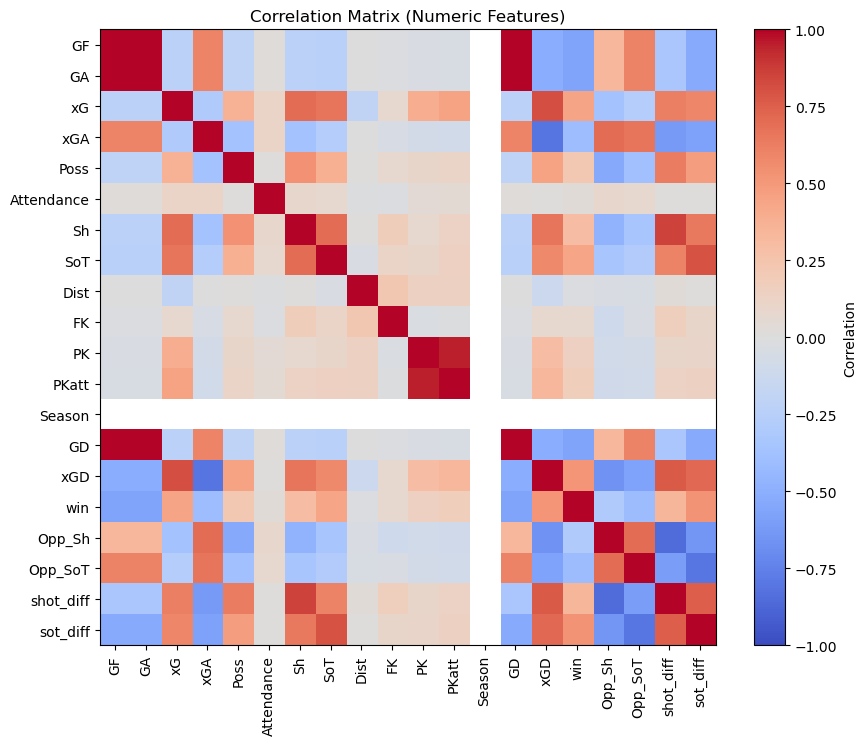

In [168]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Matrix (Numeric Features)')
plt.show()


In [169]:


win_corr = (
    epl_merged
    .select_dtypes(include='number')
    .corr()['win']
    .drop('win')
    .sort_values(ascending=False)
)

win_corr



sot_diff      0.526533
xGD           0.521826
xG            0.439397
SoT           0.437115
shot_diff     0.342229
Sh            0.292086
Poss          0.212814
PKatt         0.164804
PK            0.145379
FK            0.072284
Attendance    0.024741
Dist         -0.021744
Opp_Sh       -0.295502
xGA          -0.402958
Opp_SoT      -0.407940
GF           -0.564294
GA           -0.564294
GD           -0.564294
Season             NaN
Name: win, dtype: float64

In [170]:
from scipy.stats import pearsonr

r, p = pearsonr(epl_merged['xGD'], epl_merged['GD'])

r, p


(np.float64(-0.5118162412985043), np.float64(5.681423433888272e-52))

In [171]:
#Based on prior knowledge and data presented... will be using the following features

#sot_diff
#xGD
#Venue


# Building Model

In [172]:
features = [
    'xG',
    'xGA',
    'xGD', #Will remove XG and XGA from model because they are multicollinear and logisitic regression estimates linear coefficients
    'SoT',
    'Opp_SoT',
    'sot_diff',
    'Poss',
    'home'

]

epl_merged['home'] = (epl_merged['Venue'] == 'Home').astype(int)

model_df = (
    epl_merged[
        features + ['win']
    ]
    .dropna()
)


In [173]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    model_df,
    test_size=0.25,
    random_state=42,
    stratify=model_df['win']
)


In [174]:
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.generalized_linear_model import GLM

log_model = GLM.from_formula(
    'win ~ xGD + sot_diff + Poss + home',
    data=train_df,
    family=Binomial()
).fit()

log_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    win   No. Observations:                  570
Model:                            GLM   Df Residuals:                      565
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -272.25
Date:                Sun, 22 Feb 2026   Deviance:                       544.50
Time:                        21:16:19   Pearson chi2:                     536.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3195
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.4364      0.448      0.975      0.330      -0.441       1.314
xGD            0.6908      0.121      5.724      0.000       0.454       0.927
sot_diff       0.2589      0.040      6.501      0.000       0.181       0.337
Poss          -0.0208      0.009     -2.417      0.016      -0.038      -0.004
home          -0.1254      0.218     -0.576      0.565      -0.552       0.301
==============================================================================
"""

In [175]:
test_df.head()

,xG,xGA,xGD,SoT,Opp_SoT,sot_diff,Poss,home,win
621,0.7,0.7,0.0,2.0,2.0,0.0,61.0,1,0
555,0.3,1.6,-1.3,1.0,3.0,-2.0,28.0,0,0
205,0.9,1.2,-0.3,4.0,5.0,-1.0,71.0,0,0
150,3.1,1.7,1.4,5.0,7.0,-2.0,41.0,1,0
277,2.2,0.4,1.8,4.0,4.0,0.0,64.0,1,1


In [176]:
#Generate predictions on the test set

test_df = test_df.copy()   # good practice
test_df['Pred'] = log_model.predict(test_df)

test_df.head()

,xG,xGA,xGD,SoT,Opp_SoT,sot_diff,Poss,home,win,Pred
621,0.7,0.7,0.0,2.0,2.0,0.0,61.0,1,0,0.277367
555,0.3,1.6,-1.3,1.0,3.0,-2.0,28.0,0,0,0.173412
205,0.9,1.2,-0.3,4.0,5.0,-1.0,71.0,0,0,0.181498
150,3.1,1.7,1.4,5.0,7.0,-2.0,41.0,1,0,0.476946
277,2.2,0.4,1.8,4.0,4.0,0.0,64.0,1,1,0.555629


# Model prediction metrics

In [177]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(test_df['win'], test_df['Pred'])
roc_auc


np.float64(0.875232991612302)

# This model has strong discriminative ability:
# it assigns a higher win probability to wins than non-wins about 87% of the time


In [178]:
test_df = test_df.copy()

test_df['Pred_Label'] = (test_df['Pred'] >= 0.5).astype(int)


In [179]:
test_df.head()

,xG,xGA,xGD,SoT,Opp_SoT,sot_diff,Poss,home,win,Pred,Pred_Label
621,0.7,0.7,0.0,2.0,2.0,0.0,61.0,1,0,0.277367,0
555,0.3,1.6,-1.3,1.0,3.0,-2.0,28.0,0,0,0.173412,0
205,0.9,1.2,-0.3,4.0,5.0,-1.0,71.0,0,0,0.181498,0
150,3.1,1.7,1.4,5.0,7.0,-2.0,41.0,1,0,0.476946,0
277,2.2,0.4,1.8,4.0,4.0,0.0,64.0,1,1,0.555629,1


In [180]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    test_df['win'],
    test_df['Pred_Label']
)

accuracy


0.7894736842105263

In [181]:
#This code shows the accuracy baseline. In EPL non-wins are greater than wins due to ties... a dumb model could still get 50-60% predicting non-win for every observation.
# So you must compare to a baseline

baseline_accuracy = max(
    test_df['win'].mean(),
    1 - test_df['win'].mean()
)

baseline_accuracy


np.float64(0.6105263157894737)

# The model achieves 78% accuracy compated to a naive baseline of 61% indicating a meaningful predictive improvement, though accuracy reamins sensitive to threshold choice

In [182]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    test_df['win'],
    test_df['Pred_Label']
)

cm


array([[101,  15],
       [ 25,  49]])

In [183]:
import numpy as np
import pandas as pd

odds_ratios = pd.DataFrame({
    'coef': log_model.params,
    'odds_ratio': np.exp(log_model.params),
    'ci_lower': np.exp(log_model.conf_int()[0]),
    'ci_upper': np.exp(log_model.conf_int()[1])
})

odds_ratios


,coef,odds_ratio,ci_lower,ci_upper
Intercept,0.436361,1.547067,0.643265,3.720732
xGD,0.690770,1.995251,1.574996,2.527641
sot_diff,0.258858,1.295450,1.198189,1.400606
Poss,-0.020796,0.979419,0.963041,0.996075
home,-0.125374,0.882167,0.575752,1.351656


# Each additional shot on target increases the chances of winning by 27% on average
# Each additional expected goal increases the chances of winning by 87% on average

In [184]:
import os
os.getcwd()

'c:\\Users\\jahg9\\OneDrive\\Documents\\Data Analysis Projects\\EPL Projects'

In [185]:
epl_merged.to_csv("epl_merged.csv", index=False)